In [1]:
import os
import sys

from matplotlib.lines import Line2D
import seaborn as sns
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

plt.rcParams.update({'font.size': 22})
sns.set_style('ticks')

# Fault Detection
Now that we've trained a network to predict the $trq_{margin}$, we will move on onto the fault detection task.

In this notebook we'll train a `PyKAN` network to distinguish between *faulty* and *not-faulty* operational regimes.

## Load dataset

In [2]:
df_x, df_y = read_dataset(stage='classification')

## Train the PyKAN

In [20]:
pyKAN: PHMNetwork = PyKAN([[len(df_x.columns), 0], [1, 0], [1, 0]], 'classification', grid_size=2, device='cpu')

checkpoint directory created: ./model
saving model version 0.0


In [19]:
pyKAN.load('6-interpretable')
_, _, testset, _ = split_dataset(df_x, df_y['faulty'], train_ratio=0.01, standardize_y=False, max=1, seed=1)
pyKAN.test(testset)

100%|██████████| 59/59 [00:01<00:00, 49.22it/s]


{'test_loss': -0.8135122373952703,
 'avg_test_score': 0.8135187709421072,
 'accuracy': 0.9353475500299182,
 'precision': 0.9261574052480853,
 'recall': 0.9285219961095317,
 'f1': 0.9273381933320569,
 'cm': array([[125812,   7916],
        [  7643,  99285]], dtype=int64)}

Ok, here goes the training. If you want to repeat the training several times, say 10, with a different random trainset each time, to test the dependence of the training on the trainset selection, change `times` from 1 to 10.

- This will store the metrics results inside the `results/<prefix>.csv` file.
- The means and standard deviations used to standardize the dataset in each training, which values depend on the selected trainset, are stored inside the `results/<prefix>_norm.csv`.

In [ ]:
# 3m
pyKAN.multi_train(df_x, df_y['faulty'], epochs=300, lr=0.05, train_ratio=0.80, prefix='6-interpretable', times=1,batch_size=2048)

In [23]:
pyKAN.save('6-interpretable')

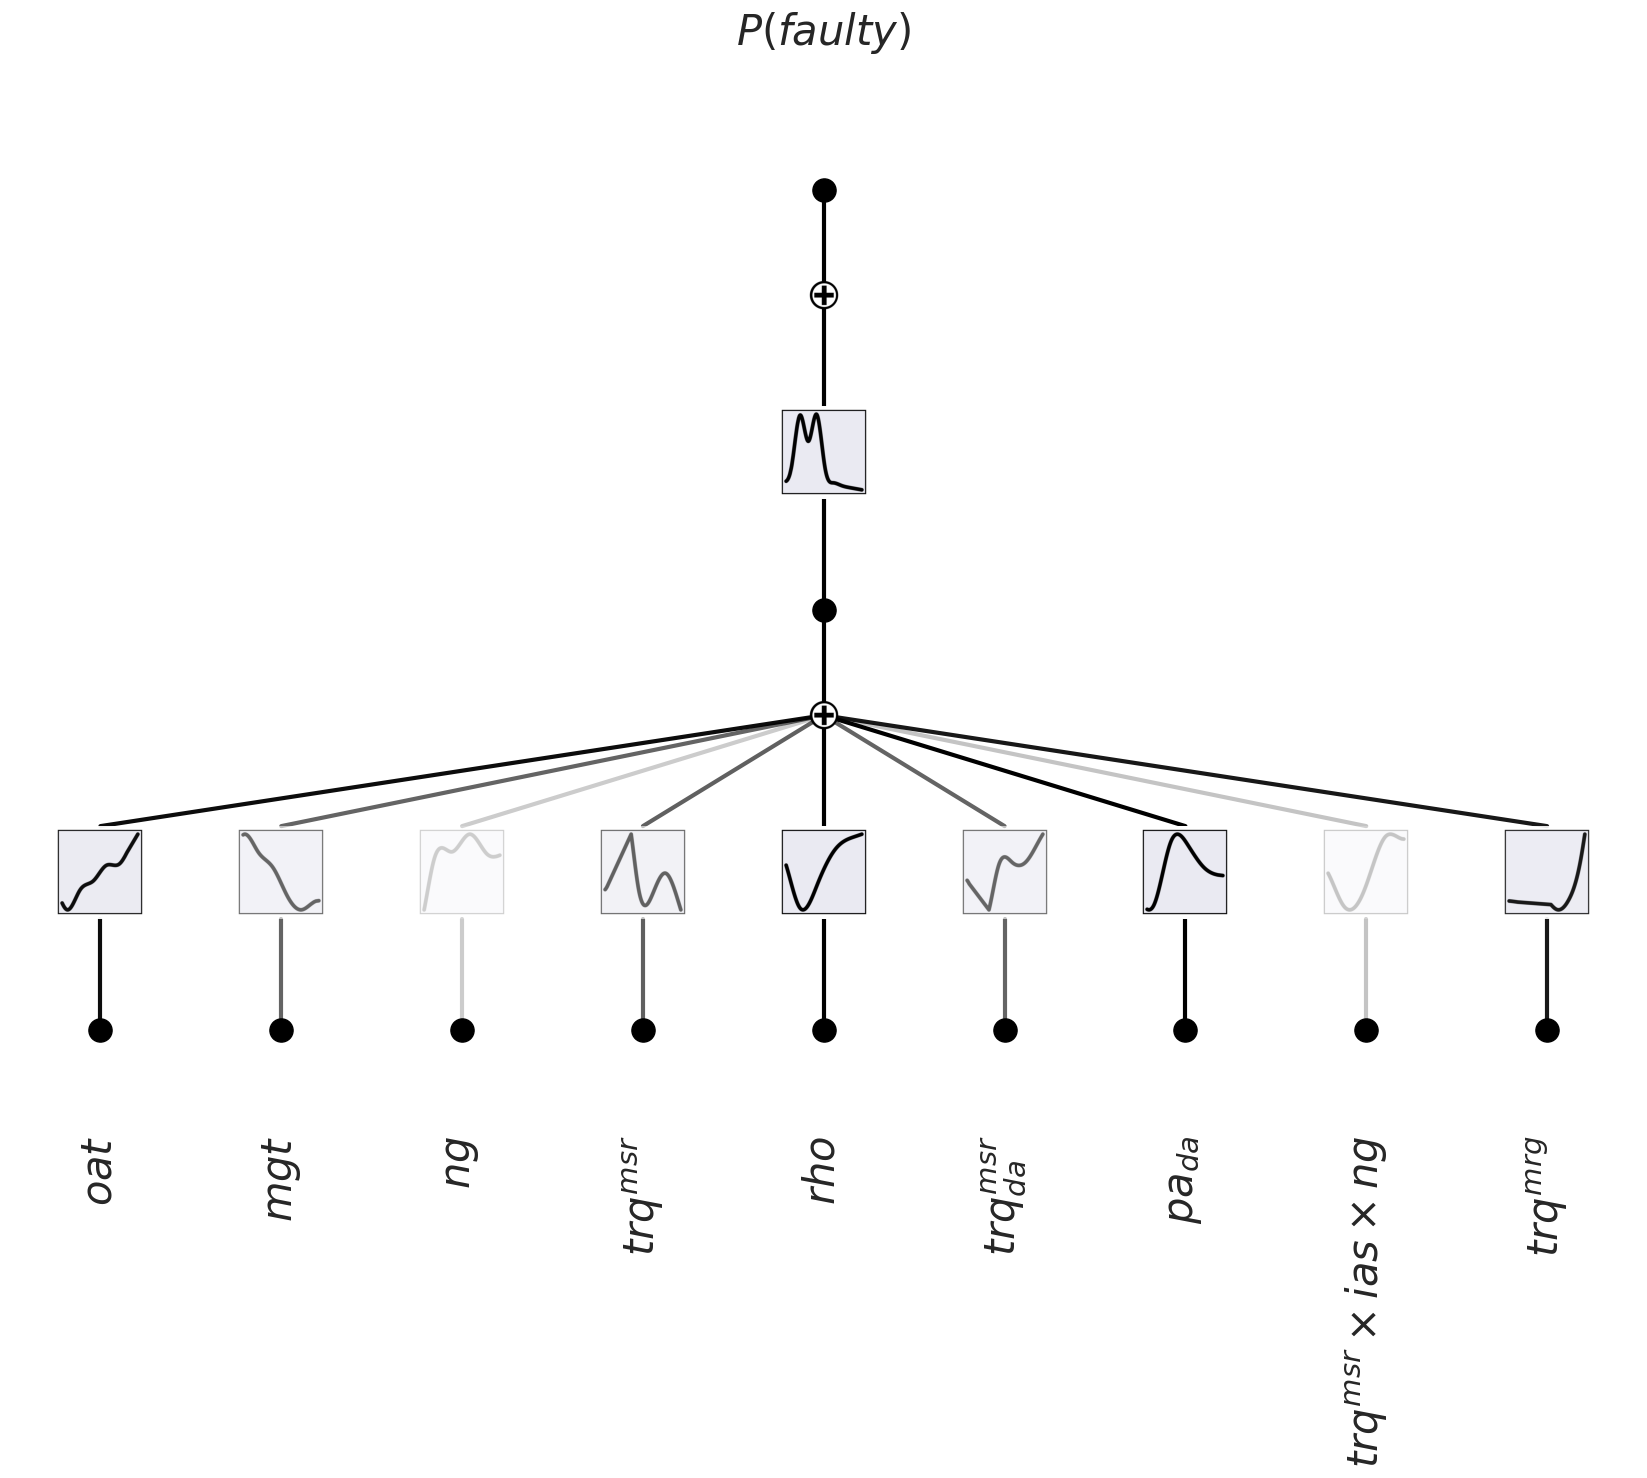

In [22]:
# 1s
pyKAN.plot(scale=1.5,in_vars=list(map(to_latex, df_x.columns)), varscale=4.5, figsize_base=(14, 10), rotate_in_vars=True)

### Visualizing the variance of the performance of the 10 trainings

Text(0.8824603525884224, 6, '$\\tilde{\\mu}_3$ = -0.535')

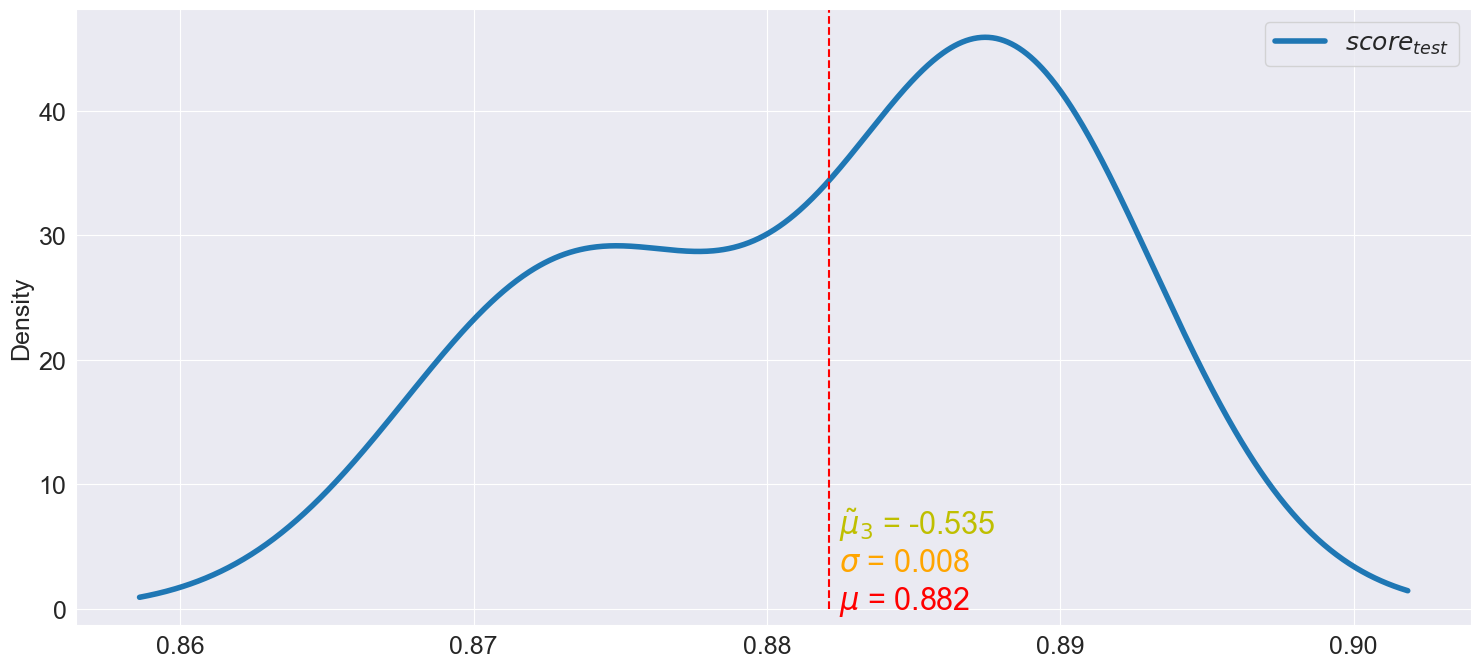

In [8]:
# 0s
result = pd.read_csv(f'results/multi_09 March 25 23-13-39.csv')
result['training'] = range(1, 11)
ax = result.plot(kind='kde', x='training', y='avg_test_score', figsize=(18, 8), linewidth=4, label='$score_{test}$')
mean = result['avg_test_score'].mean()
skew = result['avg_test_score'].skew()
std = result['avg_test_score'].std()
ax.add_line(Line2D([mean, mean], [0, 144], linestyle='--', color='red'))
ax.text(mean + 0.00035, 0, f'$\\mu$ = {mean:.3f}', fontsize=22, c='r')
ax.text(mean + 0.00035, 3, f'$\\sigma$ = {std:.3f}', fontsize=22, c='orange')
ax.text(mean + 0.00035, 6, f'$\\tilde{"{"}\\mu{"}"}_3$ = {skew:.3f}', fontsize=22, c='y')

Text(0.9619018058968557, 18, '$\\tilde{\\mu}_3$ = 0.505')

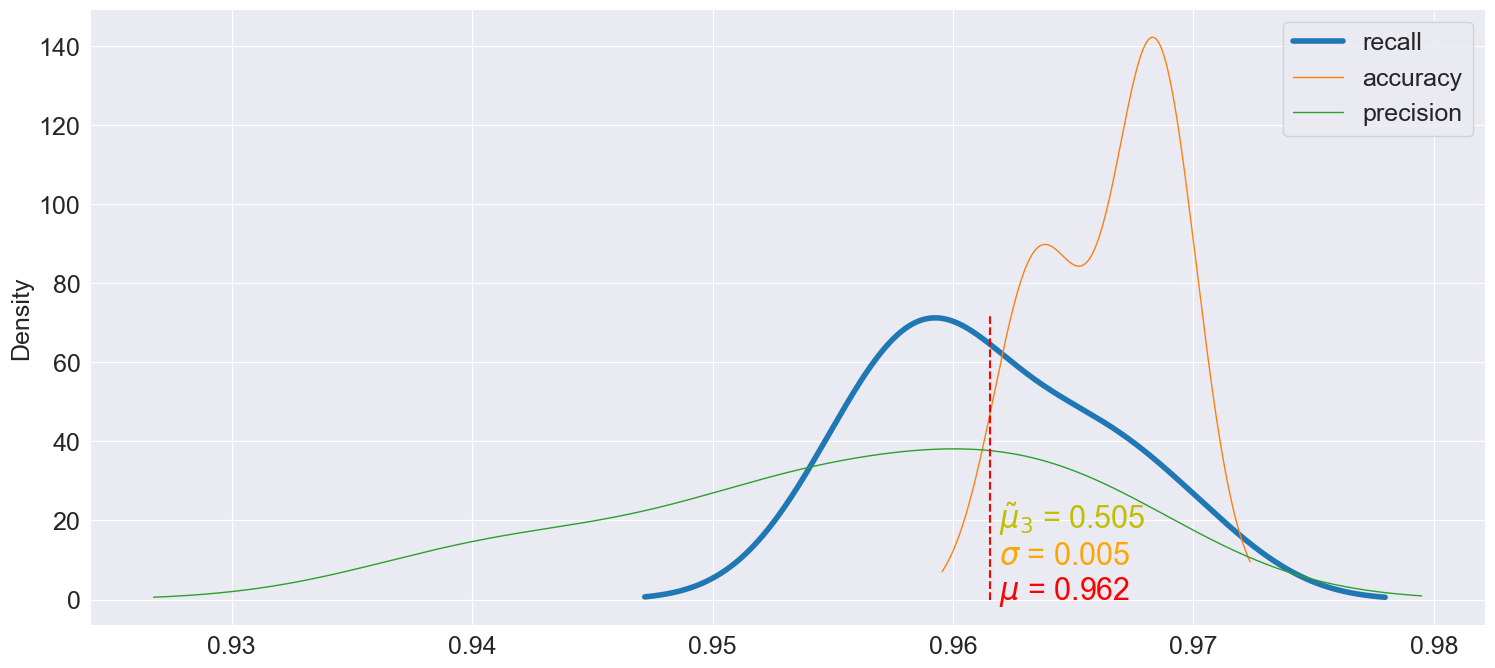

In [9]:
# 0s
result['training'] = range(1, 11)
ax = result.plot(kind='kde', x='training', y='recall', figsize=(18, 8), linewidth=4)
result.plot(kind='kde', x='training', y='accuracy', figsize=(18, 8), linewidth=1, ax=ax)
result.plot(kind='kde', x='training', y='precision', figsize=(18, 8), linewidth=1, ax=ax)
mean = result['recall'].mean()
skew = result['recall'].skew()
std = result['recall'].std()
ax.add_line(Line2D([mean, mean], [0, 72], linestyle='--', color='r'))
ax.text(mean + 0.00035, 0, f'$\\mu$ = {mean:.3f}', fontsize=22, c='r')
ax.text(mean + 0.00035, 9, f'$\\sigma$ = {std:.3f}', fontsize=22, c='orange')
ax.text(mean + 0.00035, 18, f'$\\tilde{"{"}\\mu{"}"}_3$ = {skew:.3f}', fontsize=22, c='y')